In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

prices = pd.read_csv('../data/pricing_raw.csv')

# Price relative to Walmart (Walmart = 100)
chains = ['trader_joes', 'walmart', 'aldi', 'publix', 'costco']
for chain in chains:
    prices[f'{chain}_idx'] = (prices[chain] / prices['walmart']) * 100

# Average price index per chain
print("Average Price Index (Walmart = 100, lower = cheaper):")
for chain in chains:
    avg = prices[f'{chain}_idx'].mean()
    print(f"  {chain}: {avg:.1f}")

print("\nPer-category index:")
print(prices.groupby('category')[[f'{c}_idx' for c in chains]].mean().round(1))

Average Price Index (Walmart = 100, lower = cheaper):
  trader_joes: 104.8
  walmart: 100.0
  aldi: 87.4
  publix: 133.5
  costco: 91.6

Per-category index:
           trader_joes_idx  walmart_idx  aldi_idx  publix_idx  costco_idx
category                                                                 
beverages             92.2        100.0      80.8       117.3        97.3
dairy                112.2        100.0      92.8       129.2        71.7
frozen                99.6        100.0      80.3       134.8        97.4
household             90.2        100.0      80.1       120.3        75.1
pantry                87.8        100.0      92.7       144.1        92.9
produce              133.3        100.0      95.1       130.3       102.5
proteins             120.2        100.0      95.9       151.4        89.0
snacks                86.6        100.0      70.1       130.6        98.4


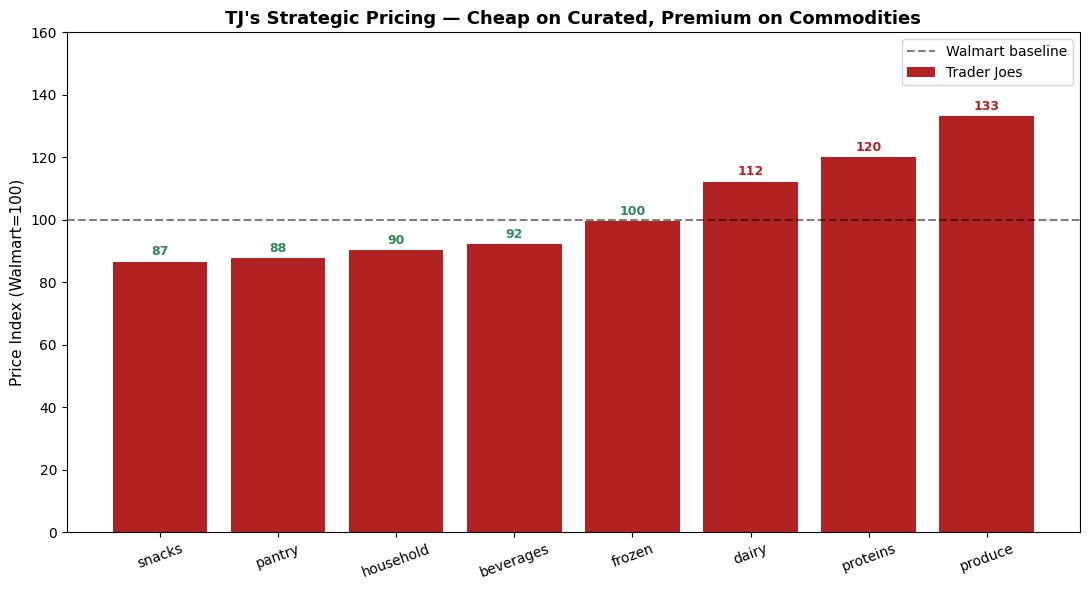

In [2]:
# Bifurcation chart — TJ vs Walmart per category
fig, ax = plt.subplots(figsize=(11, 6))

cat_idx = prices.groupby('category')[[f'{c}_idx' for c in chains]].mean()
cat_idx = cat_idx.sort_values('trader_joes_idx')

x = np.arange(len(cat_idx.index))
ax.bar(x, cat_idx['trader_joes_idx'], color='#B22222', label='Trader Joes')
ax.axhline(100, color='black', linestyle='--', alpha=0.5, label='Walmart baseline')

for i, val in enumerate(cat_idx['trader_joes_idx']):
    color = '#2E8B57' if val < 100 else '#B22222'
    ax.text(i, val + 2, f'{val:.0f}', ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(cat_idx.index, rotation=20)
ax.set_ylabel('Price Index (Walmart=100)', fontsize=11)
ax.set_title("TJ's Strategic Pricing — Cheap on Curated, Premium on Commodities", fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 160)

plt.tight_layout()
plt.savefig('../output/chart8_tj_pricing_bifurcation.png', dpi=150, bbox_inches='tight')
plt.show()